## Honey-Bee Hive Health Prediction: Final modeling

**Info:** In this notebook, we will implement our finalized model, XGBoost, on our curated dataset containing Honey-Bee health descriptors and local weather features to predict weather a hive in a given apiary is healthy in the upcoming inspection. We will use the best parameters from our previous experimentation to fit our model on training set carefully split using GroupShuffleSplit and finally test on the hold-out set. We will also extract important descriptive features driving our model. 

**Target variable**: Health status (Healthy)

**Descriptive Features:** Past Health Descriptors and Weather trends

**Train-Test split:** GroupShuffleSplit

**Models:** XGBoost

**Best Parameters:** 
- model__subsample: 0.7, 
- model__n_estimators: 200, 
- model__max_depth: 3, 
- model__learning_rate: 0.05, 
- model__colsample_bytree: 0.9

In [1]:
# Imports from standard libraries
import pandas as pd
import numpy as np
import pickle
import warnings

# Imports from sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, accuracy_score, confusion_matrix
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import MinMaxScaler

# Imports from other libraries
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', message='Found whitespace in feature_names')

In [2]:
try:
    # 1. Load Data
    print("Loading training set...")
    path_to_data = '../../data/test_train/training_data.pkl'
    with open(path_to_data, 'rb') as f:
        loaded_data = pickle.load(f)

    X_train = loaded_data["X_train"]
    groups_train = loaded_data["groups_train"]
    Y_train = loaded_data["Y_train"]

    # 2. Define Target and Features
    target = 'Healthy'
    group_key = 'HiveID'

    # 2.1 Historical and Weather Features
    health_history = [
        'Is_First_Inspection', 'Days_Since_Last_Inspection', 'Hive_Age_Days',
        'Prev_Brood_Status', 'Prev_Bees_Status', 'Prev_Queen_Status',
        'Prev_Food_Status', 'Prev_Stressors_Status', 'Prev_Space_Status']
        
    weather_features = [
        'Avg_prcp', 'Avg_wind', 'Avg_tmax', 'Avg_tmin', 'Avg_tavg',
        'Avg_snow', 'Num_frost_days']

    health_weather_features = health_history + weather_features
    features_to_use = health_weather_features

    # 3. Print Data Shapes
    print("\n--- DATA SHAPEs ---")
    print(f"X shape: {X_train.shape}")
    print(f"Y shape: {Y_train.shape}")

    # 4. Calculate scale_pos_weight for imbalance
    scale_pos_weight = (Y_train == 0).sum() / (Y_train == 1).sum()

    # 5. Create Preprocessing Pipeline
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
        ('scaler', MinMaxScaler()) 
    ])
    preprocessor = ColumnTransformer(
        transformers=[('num', numeric_transformer, features_to_use)],
        remainder='passthrough'
    )
    
    # 6. Define Model (XGBoost with Best Parameters)

    # Best Parameters from previous experimentation
    Best_Parameters = {'model__subsample': 0.7, 
                      'model__n_estimators': 200, 
                      'model__max_depth': 3, 
                      'model__learning_rate': 0.05, 
                      'model__colsample_bytree': 0.9
                      }
    
    model = xgb.XGBClassifier(
            random_state=42,
            scale_pos_weight=scale_pos_weight, n_jobs=-1,
            **Best_Parameters
        )
    
    # 7. Create Final Pipeline
    final_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    print("\nTRAINING FINAL MODEL...")
    results = final_pipeline.fit(X_train, Y_train)
    print("...MODEL TRAINED SUCCESSFULLY.")

except FileNotFoundError:
    print("\n--- ERROR ---")
    print(f"Could not find the file '{path_to_data}'.")
except Exception as e:
    print(f"An error occurred: {e}")

Loading training set...

--- DATA SHAPEs ---
X shape: (1596, 16)
Y shape: (1596,)

TRAINING FINAL MODEL...
...MODEL TRAINED SUCCESSFULLY.


#### Final test on the hold-out set


Loading test set...
...TEST SET LOADED SUCCESSFULLY.

--- FINAL TEST SET RESULTS (FINAL MODEL)---
+------------------------------------------------+
| Metric                         | Score  |
+------------------------------------------------+
| Test Accuracy                  | 0.7189 |
+------------------------------------------------+
| Test ROC-AUC                   | 0.7816 |
+------------------------------------------------+

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.77      0.74      0.75       285
           1       0.66      0.68      0.67       206

    accuracy                           0.72       491
   macro avg       0.71      0.71      0.71       491
weighted avg       0.72      0.72      0.72       491


--- PLOTTING CONFUSION MATRIX ---


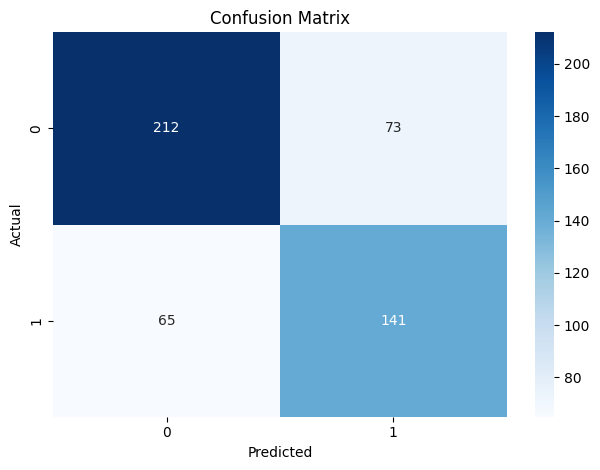


--- PLOTTING ROC CURVE ---


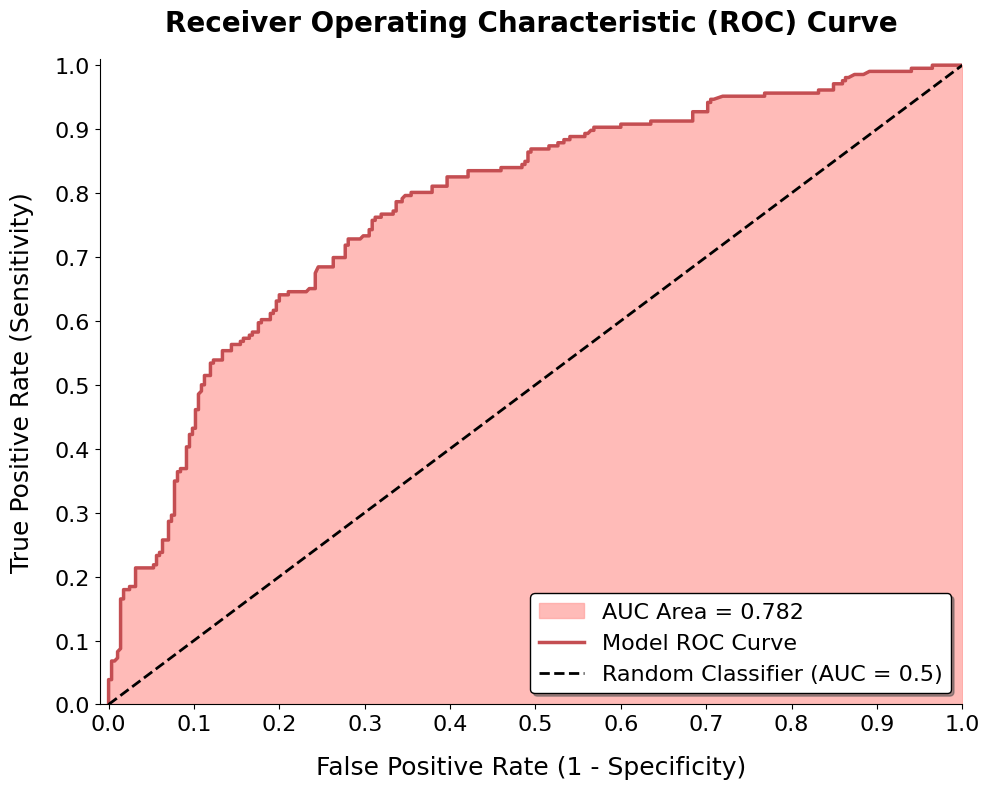

In [ ]:
try:
    # 8. Load Test Data
    print("\nLoading test set...")
    path_to_test_data = '../../data/test_train/test_data.pkl'
    with open(path_to_test_data, 'rb') as f:
        loaded_test_data = pickle.load(f)

    X_test = loaded_test_data["X_test"]
    Y_test = loaded_test_data["Y_test"]

    print("...TEST SET LOADED SUCCESSFULLY.")
    Y_pred = results.predict(X_test)
    Y_pred_proba = results.predict_proba(X_test)[:, 1]

    # 1. Print All Final Metrics
    print("\n--- FINAL TEST SET RESULTS (FINAL MODEL)---")

    # 1.1 Accuracy 

    print("+" + "-"*48 + "+")
    print(f"| {'Metric':<30} | {'Score':}  |")
    print("+" + "-"*48 + "+")
    acc = accuracy_score(Y_test, Y_pred)
    print(f"| {'Test Accuracy':<30} | {acc:.4f} |")
    print("+" + "-"*48 + "+")

    # 1.2 ROC-AUC
    auc = roc_auc_score(Y_test, Y_pred_proba)
    print(f"| {'Test ROC-AUC':<30} | {auc:.4f} |")
    print("+" + "-"*48 + "+")

    # 1.3 Classification Report
    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(Y_test, Y_pred))

    # 1.4 Plot Confusion Matrix
    print("\n--- PLOTTING CONFUSION MATRIX ---")
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('../results/confusion_matrix.png')
    plt.show()

    # 1.5 Plot ROC Curve
    print("\n--- PLOTTING ROC CURVE ---")
    import seaborn as sns
    import matplotlib.pyplot as plt

    fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba)

    # sns.set_style("whitegrid")
    pastel_fill_color = sns.color_palette("pastel")[3]
    deep_line_color = sns.color_palette("deep")[3]

    plt.figure(figsize=(10, 8))
    ax = plt.gca()

    ax.fill_between(
        fpr, tpr, 
        color=pastel_fill_color, 
        alpha=0.7, 
        label=f'AUC Area = {auc:.3f}' # Label for the filled area
    )

    ax.plot(
        fpr, tpr, 
        color=deep_line_color, 
        lw=2.5, 
        label=f'Model ROC Curve' # Label for the line
    )

    # 5.5. Plot the random classifier line
    ax.plot(
        [0, 1], [0, 1], 
        color='black', 
        linestyle='--', 
        lw=2, 
        label='Random Classifier (AUC = 0.5)'
    )

    # 5.6. Customize the plot
    ax.set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=20, fontweight='bold', pad=20)
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=18, labelpad=15)
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=18, labelpad=15)

    # Set ticks and limits
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.set_xlim([-0.01, 1.0])
    ax.set_ylim([0.0, 1.01])

    # increase tick label size
    ax.tick_params(axis='both', which='major', labelsize=16)

    legend = ax.legend(loc='lower right', fontsize=16, frameon=True, shadow=True)
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_facecolor('white')

    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    plt.savefig('../results/roc_curve.png')
    plt.show()
except FileNotFoundError:
    print("\n--- ERROR ---")
    print(f"Could not find the file '{path_to_data}'.")
except Exception as e:
    print(f"An error occurred: {e}")

### Extract the prominent features from our model

---
FEATURE IMPORTANCES ---
Prev_Queen_Status             0.251264
Is_First_Inspection           0.162842
Prev_Stressors_Status         0.132345
Prev_Bees_Status              0.064834
Num_frost_days                0.050816
Prev_Food_Status              0.049341
Avg_tavg                      0.037498
Prev_Brood_Status             0.037340
Avg_tmin                      0.032836
Avg_wind                      0.032062
Avg_tmax                      0.031420
Prev_Space_Status             0.029419
Avg_prcp                      0.028342
Days_Since_Last_Inspection    0.025774
Hive_Age_Days                 0.024164
Avg_snow                      0.009702
dtype: float32


/var/folders/nn/r9r3k78j2q12py3xmz4vtgzc0000gn/T/ipykernel_46438/2527976327.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


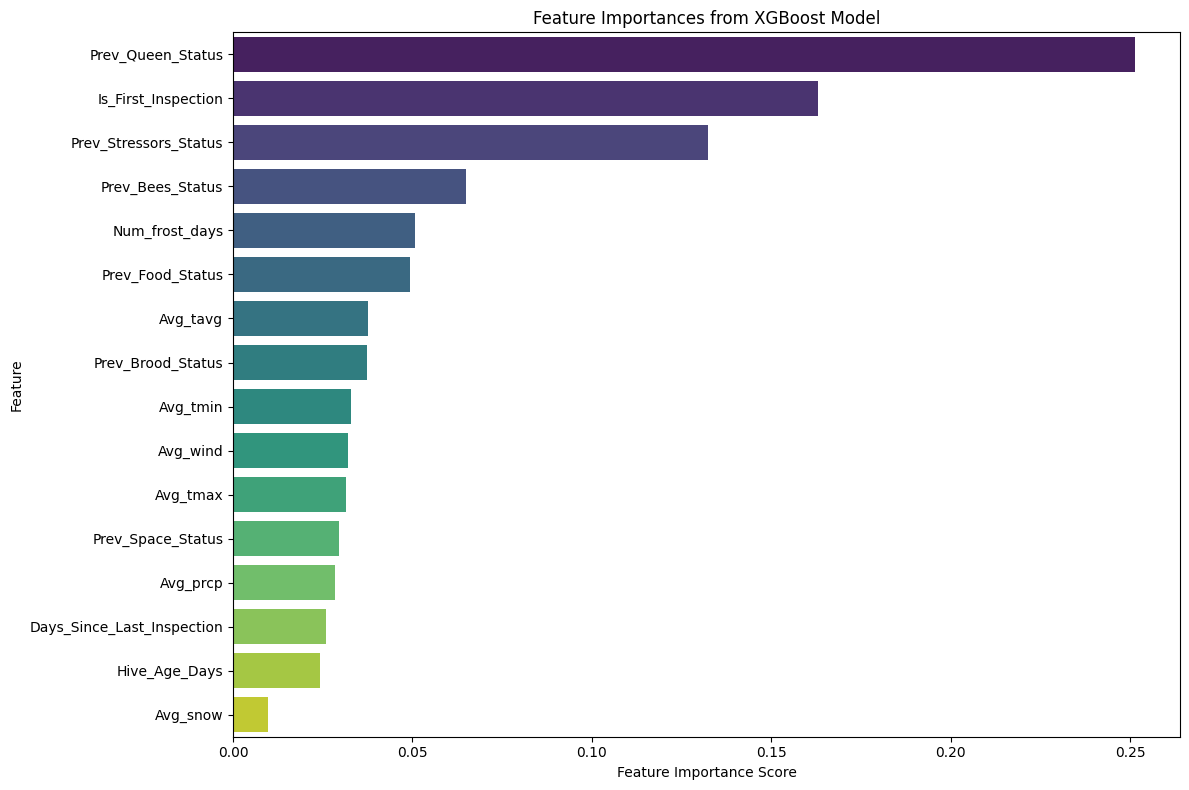

In [4]:
model = final_pipeline.named_steps['model']
preprocessor = final_pipeline.named_steps['preprocessor']

all_feature_names = health_weather_features

# 2. Create a Series of the importances
importances = pd.Series(
    model.feature_importances_, 
    index=all_feature_names
)

# 3. Sort and display the top 20
print("---\nFEATURE IMPORTANCES ---")
print(importances.sort_values(ascending=False).head(20))

# plot the feature importances
import matplotlib.pyplot as plt 
import seaborn as sns

# Create a DataFrame for the importances
df_importances = importances.sort_values(ascending=False).head(20).reset_index()
df_importances.columns = ['Feature', 'Importance']

# Create a barplot
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=df_importances,
    palette='viridis'
)
plt.xlabel('Feature Importance Score')
plt.title('Feature Importances from XGBoost Model')
plt.tight_layout()
plt.savefig('../results/feature_importances.png')
plt.show()